# FAISS Index — How It Works

**FAISS** (Facebook AI Similarity Search) is a library that finds the nearest vectors to a query vector — extremely fast, even across millions of vectors.

### Why not just use cosine similarity?

| Approach | Time complexity | 6,865 recipes | 1M recipes |
|---|---|---|---|
| Brute-force cosine (sklearn) | O(N) | fast | ~2 seconds per query |
| FAISS Flat (exact) | O(N) but vectorized | faster | ~0.3s per query |
| FAISS IVF (approximate) | O(√N) | very fast | ~5ms per query |

For 6,865 recipes both are fine, but FAISS becomes essential at scale.

### Pipeline
```
Embeddings (float32, shape N×384)
        ↓
  Normalize to unit vectors   ← needed for cosine similarity via dot product
        ↓
  Build FAISS index
        ↓
  Query: embed → normalize → index.search() → top-K recipe indices + distances
```

## Step 1 — Setup (reuse from walkthrough.ipynb)

In [1]:
import pandas as pd
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

# Load and clean data
df = pd.read_csv('../Dataset/IndianFoodDatasetCSV.csv')
df = df.dropna(subset=['RecipeName', 'TranslatedIngredients']).reset_index(drop=True)
df['TranslatedIngredients'] = df['TranslatedIngredients'].fillna('')
df['Cuisine'] = df['Cuisine'].fillna('Unknown')
df['Diet']    = df['Diet'].fillna('Unknown')
df['Course']  = df['Course'].fillna('Unknown')

df['combined_text'] = (
    df['TranslatedRecipeName'].fillna('') + ' '
    + df['TranslatedIngredients'] + ' '
    + df['Cuisine'] + ' '
    + df['Diet'] + ' '
    + df['Course']
)

# Embed all recipes
model = SentenceTransformer('all-MiniLM-L6-v2')
print('Embedding recipes...')
embeddings = model.encode(df['combined_text'].tolist(), show_progress_bar=True, batch_size=64)
print(f'Embeddings shape: {embeddings.shape}')  # (6865, 384)

/home/achyutananda-sahoo/Desktop/SMAI-A3/Assignment-3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1629.65it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding recipes...


Batches: 100%|██████████| 108/108 [00:18<00:00,  5.80it/s]

Embeddings shape: (6865, 384)


## Step 2 — Understand the Index Types

FAISS has several index types. The two most important:

### `IndexFlatIP` — Exact search using Inner Product (dot product)
- Compares query against **every** vector (brute-force, but SIMD-optimized)
- **Exact** results — no approximation
- Use when N < ~500K

### `IndexIVFFlat` — Approximate search using Inverted File Index
- Splits vectors into `nlist` clusters (like k-means)
- At query time, only searches `nprobe` nearest clusters instead of all
- **Approximate** but much faster at large N
- Requires a **training step** to build the clusters

> For cosine similarity we **L2-normalize** all vectors first, then use Inner Product.
> Dot product of two unit vectors = cosine similarity.

## Step 3 — Build an Exact FAISS Index (`IndexFlatIP`)

In [12]:
# FAISS requires float32
vecs = embeddings.astype('float32')

# L2-normalize so inner product == cosine similarity
faiss.normalize_L2(vecs)

DIM = vecs.shape[1]   # 384

# Build exact flat index
index_flat = faiss.IndexFlatIP(DIM)
index_flat.add(vecs)

print(f'Index type     : {type(index_flat).__name__}')
print(f'Vectors stored : {index_flat.ntotal}')
print(f'Dimension      : {DIM}')

Index type     : IndexFlatIP
Vectors stored : 6865
Dimension      : 384


## Step 4 — Query the Flat Index

In [13]:
def search(query, index, top_k=5):
    q = model.encode([query]).astype('float32')
    faiss.normalize_L2(q)                    # normalize query too
    distances, indices = index.search(q, top_k)
    # distances = cosine similarity scores (higher = more similar)
    # indices   = row positions in df
    results = df.iloc[indices[0]][['TranslatedRecipeName', 'Cuisine', 'Diet', 'TotalTimeInMins']].copy()
    results['cosine_sim'] = distances[0].round(3)
    return results.reset_index(drop=True)

search('paneer, tomato, cream, onion', index_flat, top_k=5)

,TranslatedRecipeName,Cuisine,Diet,TotalTimeInMins,cosine_sim
0,UP Style Paneer In Mustard Gravy Recipe,Uttar Pradesh,Vegetarian,30,0.761
1,Paneer Onion Paratha Recipe,North Indian Recipes,High Protein Vegetarian,45,0.746
2,Tomatoes Stuffed With Mint Mayo And Paneer Recipe,Continental,Vegetarian,50,0.741
3,Paneer in Yogurt Tomato Curry (Recipe In Hindi),Kashmiri,Vegetarian,50,0.732
4,Spicy Tandoori Paneer Open Puff Recipe,French,Vegetarian,155,0.729


## Step 5 — Build an Approximate Index (`IndexIVFFlat`)

IVF splits the vector space into `nlist` Voronoi cells (clusters).  
At query time, only `nprobe` cells are searched — trading a little accuracy for a lot of speed.

```
All vectors
    │
    ├── Cluster 0  [recipes about rice, dal ...]
    ├── Cluster 1  [recipes about chicken ...]
    ├── Cluster 2  [recipes about sweets ...]
    └── ...  (nlist clusters total)

Query "paneer butter masala"
    → find 2 nearest clusters (nprobe=2)
    → only search those clusters
    → much fewer comparisons
```

**Rule of thumb:** `nlist = 4 × sqrt(N)`, `nprobe = nlist / 10`

In [11]:
N     = len(vecs)
nlist = max(10, int(4 * np.sqrt(N)))   # ~332 clusters for 6865 recipes
nprobe = max(1, nlist // 10)           # search ~33 clusters per query

print(f'N={N}, nlist={nlist}, nprobe={nprobe}')

# IVF needs a quantizer (how to measure distance inside each cluster)
quantizer = faiss.IndexFlatIP(DIM)
index_ivf  = faiss.IndexIVFFlat(quantizer, DIM, nlist, faiss.METRIC_INNER_PRODUCT)

# Training: k-means to find cluster centroids
index_ivf.train(vecs)
index_ivf.add(vecs)
index_ivf.nprobe = nprobe

print(f'IVF index trained and ready. Vectors: {index_ivf.ntotal}')

N=6865, nlist=331, nprobe=33


WARNING clustering 6865 points to 331 centroids: please provide at least 12909 training points


IVF index trained and ready. Vectors: 6865


In [10]:
# Same query, approximate index
search('paneer, tomato, cream, onion', index_ivf, top_k=5)

,TranslatedRecipeName,Cuisine,Diet,TotalTimeInMins,cosine_sim
0,UP Style Paneer In Mustard Gravy Recipe,Uttar Pradesh,Vegetarian,30,0.761
1,Paneer Onion Paratha Recipe,North Indian Recipes,High Protein Vegetarian,45,0.746
2,Tomatoes Stuffed With Mint Mayo And Paneer Recipe,Continental,Vegetarian,50,0.741
3,Paneer in Yogurt Tomato Curry (Recipe In Hindi),Kashmiri,Vegetarian,50,0.732
4,Spicy Tandoori Paneer Open Puff Recipe,French,Vegetarian,155,0.729


## Step 5b — Visualise the IVF Clusters

The IVF index groups all recipe vectors into  clusters using k-means.
We reduce the 384-D embeddings to 2-D with PCA, then colour each point by its cluster assignment.
Nearby clusters in the plot = recipes with similar flavour/ingredient profiles.

Cluster sizes  min: 1  max: 105  mean: 20.7
Variance explained by 2 PCs: 23.9%


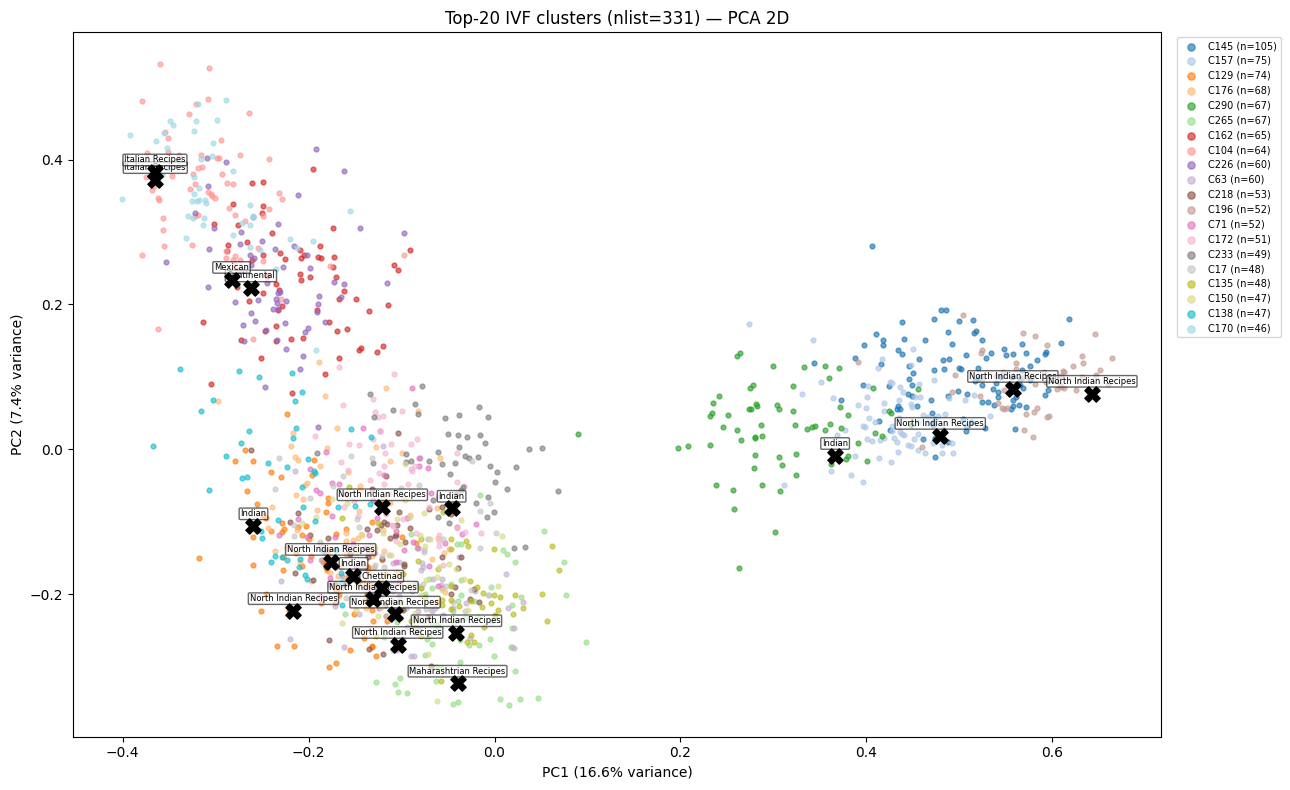

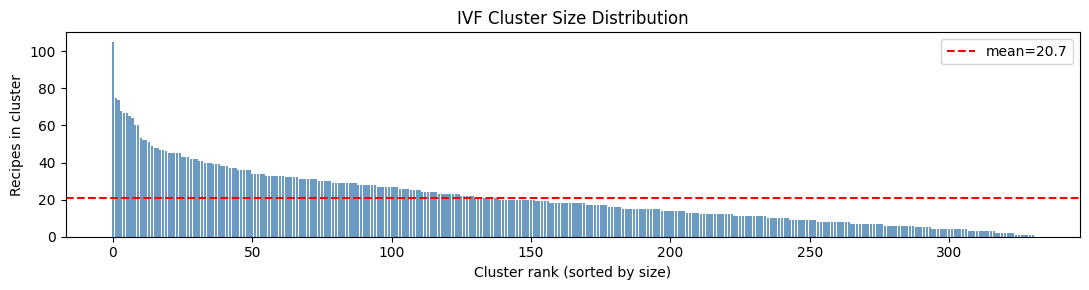

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- Get cluster assignment for every recipe ---
_, cluster_ids = index_ivf.quantizer.search(vecs, 1)  # shape (N, 1)
cluster_ids = cluster_ids.flatten()                    # shape (N,)

# --- Get centroids directly (returns numpy array in faiss >= 1.7) ---
centroids = index_ivf.quantizer.reconstruct_n(0, nlist)  # (nlist, DIM)

# --- Cluster sizes ---
sizes = np.bincount(cluster_ids, minlength=nlist)
print(f"Cluster sizes  min: {sizes.min()}  max: {sizes.max()}  mean: {sizes.mean():.1f}")

# Keep only top-20 largest clusters so the scatter stays readable
TOP_CLUSTERS = 20
top_cids = np.argsort(sizes)[::-1][:TOP_CLUSTERS]
mask_top = np.isin(cluster_ids, top_cids)

# --- PCA 384D -> 2D on a sample of points from top clusters ---
SAMPLE = 2000
candidates = np.where(mask_top)[0]
rng = np.random.default_rng(42)
sample_idx = rng.choice(candidates, min(SAMPLE, len(candidates)), replace=False)

pca    = PCA(n_components=2)
coords = pca.fit_transform(vecs[sample_idx])
labels = cluster_ids[sample_idx]
print(f"Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}")

# --- Plot 1: scatter coloured by cluster ---
cmap = plt.colormaps["tab20"].resampled(TOP_CLUSTERS)
fig, ax = plt.subplots(figsize=(13, 8))
for i, cid in enumerate(top_cids):
    pts = coords[labels == cid]
    ax.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.65, color=cmap(i), label=f"C{cid} (n={sizes[cid]})")

# Overlay centroids
centroid_2d = pca.transform(centroids[top_cids])
ax.scatter(centroid_2d[:, 0], centroid_2d[:, 1], marker="X", s=120, c="black", zorder=5)

# Annotate each centroid with dominant cuisine
for i, cid in enumerate(top_cids):
    members = df[cluster_ids == cid]
    top_cuisine = members["Cuisine"].value_counts().idxmax()
    ax.annotate(top_cuisine, centroid_2d[i], fontsize=6, ha='center',
                xytext=(0, 7), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.6))

ax.legend(fontsize=7, markerscale=1.5, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_title(f"Top-{TOP_CLUSTERS} IVF clusters (nlist={nlist}) — PCA 2D")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()
plt.show()

# --- Plot 2: cluster size distribution ---
fig2, ax2 = plt.subplots(figsize=(11, 3))
ax2.bar(range(len(sizes)), sorted(sizes, reverse=True), color='steelblue', alpha=0.8)
ax2.axhline(sizes.mean(), color="red", linestyle="--", label=f"mean={sizes.mean():.1f}")
ax2.set_xlabel('Cluster rank (sorted by size)')
ax2.set_ylabel('Recipes in cluster')
ax2.set_title('IVF Cluster Size Distribution')
ax2.legend()
plt.tight_layout()
plt.show()


## Step 6 — Speed Comparison: Brute-force vs FAISS Flat vs FAISS IVF

In [5]:
import time
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cos

query      = 'rice, lentil, cumin, mustard seeds'
query_vec  = model.encode([query]).astype('float32')
query_norm = query_vec.copy()
faiss.normalize_L2(query_norm)
REPS = 50

# --- Brute-force sklearn ---
t0 = time.perf_counter()
for _ in range(REPS):
    scores = sklearn_cos(query_vec, embeddings)[0]
    _ = np.argsort(scores)[::-1][:10]
t_sklearn = (time.perf_counter() - t0) / REPS * 1000

# --- FAISS Flat ---
t0 = time.perf_counter()
for _ in range(REPS):
    index_flat.search(query_norm, 10)
t_flat = (time.perf_counter() - t0) / REPS * 1000

# --- FAISS IVF ---
t0 = time.perf_counter()
for _ in range(REPS):
    index_ivf.search(query_norm, 10)
t_ivf = (time.perf_counter() - t0) / REPS * 1000

print(f'Brute-force (sklearn) : {t_sklearn:.2f} ms per query')
print(f'FAISS Flat (exact)    : {t_flat:.2f} ms per query')
print(f'FAISS IVF  (approx)   : {t_ivf:.2f} ms per query')

Brute-force (sklearn) : 18.17 ms per query
FAISS Flat (exact)    : 1.06 ms per query
FAISS IVF  (approx)   : 0.17 ms per query


## Step 7 — Accuracy: Does IVF (Approximate) Miss Any Results?

Compare top-10 results from Flat (exact) vs IVF (approximate) — measure **recall**.

In [6]:
test_queries = [
    'paneer, tomato, cream',
    'chicken, ginger, garlic, spices',
    'rice, coconut, curry leaves',
    'dal, lentil, turmeric',
    'potato, peas, cumin',
]
K = 10
recalls = []

for q in test_queries:
    qv = model.encode([q]).astype('float32')
    faiss.normalize_L2(qv)

    _, idx_flat = index_flat.search(qv, K)
    _, idx_ivf  = index_ivf.search(qv, K)

    exact_set = set(idx_flat[0])
    approx_set = set(idx_ivf[0])
    recall = len(exact_set & approx_set) / K
    recalls.append(recall)
    print(f'Query: "{q}" → recall@{K} = {recall:.0%}')

print(f'\nMean recall@{K}: {np.mean(recalls):.0%}')

Query: "paneer, tomato, cream" → recall@10 = 100%
Query: "chicken, ginger, garlic, spices" → recall@10 = 100%
Query: "rice, coconut, curry leaves" → recall@10 = 90%
Query: "dal, lentil, turmeric" → recall@10 = 100%
Query: "potato, peas, cumin" → recall@10 = 80%

Mean recall@10: 94%


## Step 8 — Save Index to Disk

Building the index every time is wasteful. Save once, load on startup.

In [7]:
# Save
faiss.write_index(index_ivf, 'recipe_index.faiss')
print('Index saved to recipe_index.faiss')

# Load
loaded_index = faiss.read_index('recipe_index.faiss')
loaded_index.nprobe = nprobe
print(f'Loaded index with {loaded_index.ntotal} vectors')

Index saved to recipe_index.faiss
Loaded index with 6865 vectors


## Step 9 — Drop-in Replacement for the Recommender

How `main.py` would change — just swap the similarity call:

In [ ]:
# BEFORE (brute-force)
# scores   = cosine_similarity(query_vec, embeddings)[0]
# top_idx  = np.argsort(scores)[::-1][:top_k]

# AFTER (FAISS)
def recommend_faiss(query_text, index, top_k=10):
    q = model.encode([query_text]).astype('float32')
    faiss.normalize_L2(q)
    distances, indices = index.search(q, top_k)
    results = df.iloc[indices[0]][['TranslatedRecipeName', 'Cuisine', 'Diet', 'Course', 'TotalTimeInMins']].copy()
    results['similarity'] = distances[0].round(3)
    return results.reset_index(drop=True)

recommend_faiss('dal, lentil, spinach, garlic', index_ivf)

## Summary

| | Brute-force | FAISS Flat | FAISS IVF |
|---|---|---|---|
| Search type | Exact | Exact | Approximate |
| Speed | Slow at scale | Fast | Fastest |
| Memory | High (full matrix) | High | Low (clusters) |
| Recall | 100% | 100% | ~95-99% |
| Needs training | No | No | Yes |
| Best for | < 10K vectors | < 500K vectors | > 100K vectors |

For 6,865 recipes, **FAISS Flat** is the sweet spot — exact results, faster than sklearn, no training needed.